# PROYECTO PRACTICO 1
## OBJETIVO: Aplicar el flujo de trabajo de datos geoespaciales en la nube (CDSE, leafmap, rasterio y xarray) para realizar un análisis multitemporal de detección de cambios en un área de estudio de su elección.
### xx

# 1. Configuració inicial
## 1.1. Alistar las librerias de base necesarias para el ejercicio
### El objetivo de esta primera sección es importar las librerias necesarias para llevar acabo el ejercicio

In [4]:
#Sistema central
import os #permite interactuar con el sistema operativo, por ejemplo, acceder a variables de entorno, rutas y archivos
import re #permite buscar, identificar y manipular patrones de texto mediante expresiones regulares.
import requests #permite realizar solicitudes HTTP/HTTPS para consultar y descargar información desde servicios web o APIs

#Autenticación en la nube de AWS e interfaz de S3
#estas librerias pueden presentar problemas dependeindo del estado de la internet o de la capasidad de memoria RAM
import boto3 # permite conectarse y trabajar con servicios de Amazon Web Services (AWS), como S3, para autenticar y acceder a archivos almacenados en la nube
from rasterio.session import AWSSession #permite integrar las credenciales y la sesión de AWS de boto3 con Rasterio/GDAL para acceder a datos raster almacenados en servicios S3

# Análisis geooespacial
import numpy as np #permite realizar operaciones numéricas y matemáticas eficientes sobre matrices y arreglos
import rasterio #permite leer, escribir y procesar datos raster geoespaciales, como imágenes satelitales GeoTIFF o JP2.
from rasterio.windows import from_bounds #permite crear una ventana de lectura de un raster a partir de las coordenadas de los límites de un área de interés (AOI)
from rasterio.mask import mask #permite recortar un raster utilizando la geometría de una capa vectorial
import geopandas as gpd #permite leer, manipular, transformar y analizar datos vectoriales geoespaciales,

#Visualización
import matplotlib.pyplot as plt #permite crear gráficos y visualizar datos, como mapas, histogramas, curvas y otras figuras.
import leafmap.maplibregl as leafmap #permite crear mapas interactivos y visualizar datos geoespaciales

## 1.2. Credenciales Copernicus
### El objetivo de esta seccion es acceder por medio de las llaves a los datos del ecosistema de Copernicus

In [7]:
#Para ptener las credenciales toca antes acceder a la plataforma de Copernicus y crear las llaves
os.environ["AWS_ACCESS_KEY_ID"] ="V6LPFKBFFK9GERPFBPO0"
os.environ["AWS_SECRET_ACCESS_KEY"] = "Jq4BeOtTeZy8ky4VJRmX9wQHD0ab1jgmNWdBwMkc"
os.environ["AWS_S3_ENDPOINT"] = "eodata.dataspace.copernicus.eu"
os.environ["AWS_VIRTUAL_HOSTING"] = "FALSE"
os.environ["GDAL_HTTP_UNSAFESSL"] = "YES"
os.environ["AWS_HTTPS"] = "YES"
os.environ["GDAL_HTTP_TCP_KEEPALIVE"] = "YES"

# 2. Cargar área de estudio 
### El objetivo de esta seccion es indicar la ruta donde está almacenado el archivo vectorial que fucnionará como mascara para delimitar el área geográfica de trabajo
### Tambien muestra el sistema de coordenadas del área de estudio, sus geometrías y tablas de atributos

In [8]:
from pathlib import Path #permite trabajar de forma sencilla y segura con rutas de archivos y carpetas

#se trabajara sobre el departamento de Putumayo, shape almacenado en la carpeta de trabajo
root_folder = Path(r"C:\Users\Leo\Documents\GEOPROCESAMIENTO\Proyecto1\Dep_Putumayo")

# Ajusta el nombre exacto de tu archivo .shp
gdf_aoi = gpd.read_file(root_folder / "Departamento_Putumayo.shp")

print("CRS original:", gdf_aoi.crs) #muestra el sistema de coordenadas (CRS) del AOI
print("Número de geometrías:", len(gdf_aoi)) #muestra cuántas geometrías/entidades contiene el AOI.
gdf_aoi.head() #muestra las primeras 5 filas de la tabla de atributos

CRS original: EPSG:9377
Número de geometrías: 1


,DeCodigo,DeNombre,DeArea,DeNorma,Shape_Leng,Shape_Area,Class,geometry
0,86,Putumayo,25701.41141,ConstituciÃ³n PolÃ­tica de Colombia 1991,1.410906e+06,2.570141e+10,1,"POLYGON ((4591376.253 1720501.82, 4591431.122 ..."


### Verificación del área de estudio

<Axes: >

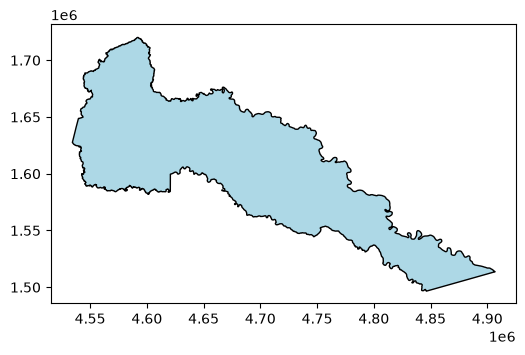

In [9]:
gdf_aoi.plot(figsize=(6,6), edgecolor="black", color="lightblue")

## 2.1 Extrar centroide, esto se utilizará luego en los mapas dinámicos
### El objetivo de este paso es ubicar un punto en el centro del área de estudio para construir mapas dinámicos.
### Este mapa dinámico permitirá dibujar una parcela en el area geográfica que sera la que analizaremos. 
### Esta consideración se determinó porque el Putumayo es un área muy grande.

In [10]:
centroid_point = gdf_aoi.to_crs(epsg=4326).geometry.centroid.iloc[0]
centroid_lat = centroid_point.y
centroid_lon = centroid_point.x
print(f"Centroide: lat={centroid_lat}, lon={centroid_lon}")

Centroide: lat=0.457947122320159, lon=-75.86179021183258


## 2.2. Selección de área de estudio manejable dentro de putumayo

### Te va a mostrar un mapa interactivo con el contorno de Putumayo en rojo sobre una imagen satelital. En la barra de herramientas del mapa (generalmente a la izquierda o arriba), deberías ver íconos de dibujo (rectángulo, polígono, etc.).

### Dibuja una parcela  sobre la zona de Putumayo que te interese (recomendación: algo de unos 15-25 km de lado, para mantenerlo rápido).

In [11]:
import leafmap ## Permite mapas dinámicos

# Centrar el mapa en Putumayo
centroid_putumayo = gdf_aoi.to_crs(epsg=4326).geometry.centroid.iloc[0]

m_select = leafmap.Map(
    center=[centroid_putumayo.y, centroid_putumayo.x],
    zoom=9
)

# Mostrar el límite del departamento como referencia
#esto perimitira seleccionar una parcela en el área de estudio
m_select.add_gdf(gdf_aoi.to_crs(epsg=4326), layer_name="Putumayo", fill_colors=["#00000000"], style={"color": "red", "weight": 2, "fillOpacity": 0})

# Agregar basemap satelital para ubicarte mejor visualmente
m_select.add_basemap("Esri.WorldImagery")

m_select

Map(center=[0.457947122320159, -75.86179021183258], controls=(ZoomControl(options=['position', 'zoom_in_text',…

### Permitirá tomar el área que dibujaste en m_select y la convierte en un GeoDataFrame, para lueego utilizarlo como área de estudio

In [13]:
if m_select.user_roi is not None: #comprueba si ya existe una geometría dibujada.
    from shapely.geometry import shape
    
    geom = shape(m_select.user_roi["geometry"]) if "geometry" in m_select.user_roi else shape(m_select.user_roi) #convierte la geometría GeoJSON dibujada en una geometría de Shape
    
    gdf_aoi_seleccionado = gpd.GeoDataFrame(
        {"geometry": [geom]}, 
        crs="EPSG:4326"
    ) #queda siendo tu nuevo AOI e área seleccionada
    print("✅ AOI seleccionado correctamente")
    print(gdf_aoi_seleccionado)
else:
    print("⚠️ Aún no has dibujado nada en el mapa") # para verificar si realmente se selecciono una parcela

✅ AOI seleccionado correctamente
                                            geometry
0  POLYGON ((-76.67721 0.39415, -76.67721 0.68802...


## 2.3. Seleccionat los limiter de la parcela AOI
### Esta informacipon se requerirá para la seleccion de datos Sentinel

In [14]:
bounds_sel = gdf_aoi_seleccionado.total_bounds
min_lon, min_lat, max_lon, max_lat = bounds_sel
print("Bounding box del AOI seleccionado:", bounds_sel)

Bounding box del AOI seleccionado: [-76.677208   0.394149 -76.421823   0.688019]


# 3. Seleccion de datos Sentinel2
### El objetivo de este paso es buscas imágenes Sentinel-2 L2A en el catálogo de Copernicus Data Space que intersecten tu AOI

In [15]:
# La función search_sentinel2_odata() recibe las coordenadas que delimitan el AOI, 
#las fechas inicial y final del periodo de búsqueda, 
#el porcentaje máximo de nubosidad permitido
#el número máximo de imágenes a obtener. Por defecto, busca imágenes con hasta 10 % de nubosidad y devuelve como máximo 20 resultados.

def search_sentinel2_odata(min_lon, min_lat, max_lon, max_lat, start_date, end_date, max_cloud=10, max_results=20):
    url = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
    
    poly = f"POLYGON(({min_lon} {min_lat}, {max_lon} {min_lat}, {max_lon} {max_lat}, {min_lon} {max_lat}, {min_lon} {min_lat}))" #Usa la parcela AOI
    
    filter_query = (
        f"Collection/Name eq 'SENTINEL-2' and "
        f"Attributes/StringAttribute/any(att:att/Name eq 'productType' and att/Value eq 'S2MSI2A') and "
        f"Attributes/DoubleAttribute/any(att:att/Name eq 'cloudCover' and att/Value le {max_cloud}) and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{poly}') and "
        f"ContentDate/Start ge {start_date}T00:00:00.000Z and "
        f"ContentDate/Start le {end_date}T23:59:59.999Z"
    ) #Constituye los filtros para determinar el sensor, % de nuber y un rango de fechas
    
    params = {
        "$filter": filter_query,
        "$orderby": "ContentDate/Start desc",
        "$top": max_results,
    }
    
    response = requests.get(url, params=params) #Genera la solicitud a la API Copernicus
    data = response.json()
    items = data.get("value", [])
    
    results = []
    print(f"Encontradas {len(items)} escenas con <{max_cloud}% de nubes.\n" + "="*60)
    
    for idx, item in enumerate(items):
        s3_path = item.get("S3Path", "")
        date = item.get("ContentDate", {}).get("Start", "").split("T")[0]
        match = re.search(r"_(T\d{2}[A-Z]{3})_", s3_path)
        tile_id = match.group(1) if match else None
        
        results.append({"index": idx, "date": date, "tile": tile_id, "s3_path": s3_path})
        print(f"[{idx}] 📅 {date} | 🧩 Tile: {tile_id}")
        print(f"    📦 {s3_path}\n")
    
    return results # Muestra los resultados

## 3.1. seección de dos momentos 
### El objetivo de este paso es buscar y obtener imágenes Sentinel-2 para dos épocas climáticas diferentes de 2025

In [16]:
print("### TEMPORADA SECA 2025 (Dic 2024 - Feb 2025) ###")
resultados_seca = search_sentinel2_odata(min_lon, min_lat, max_lon, max_lat, "2024-12-01", "2025-02-28", max_cloud=30)

print("\n### TEMPORADA HÚMEDA 2025 (Abr - Jul 2025) ###")
resultados_humeda = search_sentinel2_odata(min_lon, min_lat, max_lon, max_lat, "2025-04-01", "2025-07-31", max_cloud=30)

### TEMPORADA SECA 2025 (Dic 2024 - Feb 2025) ###
Encontradas 2 escenas con <30% de nubes.
[0] 📅 2025-01-22 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NUF_20250122T184057.SAFE

[1] 📅 2024-12-03 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2024/12/03/S2A_MSIL2A_20241203T152651_N0511_R025_T18NUF_20241203T202551.SAFE


### TEMPORADA HÚMEDA 2025 (Abr - Jul 2025) ###
Encontradas 2 escenas con <30% de nubes.
[0] 📅 2025-07-06 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/07/06/S2B_MSIL2A_20250706T152659_N0511_R025_T18NUF_20250706T203645.SAFE

[1] 📅 2025-06-11 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/06/11/S2C_MSIL2A_20250611T152711_N0511_R025_T18NUF_20250611T220016.SAFE



## 3.2. Seleccionar una imagen Sentinel-2 representativa para la temporada seca y otra para la temporada húmeda

In [29]:
# Usamos los resultados de la búsqueda directamente, sin copiar rutas a mano
seca_elegida = resultados_seca[0]      # 2025-01-22, T18NUF
humeda_elegida = resultados_humeda[1]  # 2025-06-11, T18NUF (misma tile, buena señal)

#Extrae la ruta de almacenamiento S3
s3_path_seca = seca_elegida["s3_path"]
s3_path_humeda = humeda_elegida["s3_path"]
tile_seca = seca_elegida["tile"]
tile_humeda = humeda_elegida["tile"]

print("Estado 1 (seca):", s3_path_seca, "| Tile:", tile_seca)
print("Estado 2 (húmeda):", s3_path_humeda, "| Tile:", tile_humeda)

#comprueba que las dos imágenes pertenecen al mismo tile Sentinel-2
assert tile_seca == tile_humeda, "⚠️ Las fechas están en tiles distintos, elige otra combinación"

Estado 1 (seca): /eodata/Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NUF_20250122T184057.SAFE | Tile: T18NUF
Estado 2 (húmeda): /eodata/Sentinel-2/MSI/L2A/2025/06/11/S2C_MSIL2A_20250611T152711_N0511_R025_T18NUF_20250611T220016.SAFE | Tile: T18NUF


## 3.2 Construir el índice NDWI
### El objetivo es localizas dentro del producto Sentinel-2 .SAFE la carpeta GRANULE y establece la conexión con el almacenamiento S3 de Copernicus

In [18]:
# find_granule_path Crea una función que recibe la ruta S3 de una imagen Sentinel-2 y el cliente de conexión S3.
def find_granule_path(s3_path, s3_client):
    """Busca la subcarpeta GRANULE dentro del producto .SAFE"""
    prefix = s3_path.lstrip("/eodata/") + "/GRANULE/"
    response = s3_client.list_objects_v2(Bucket="eodata", Prefix=prefix, Delimiter="/")
    folders = response.get("CommonPrefixes", [])
    if folders:
        return folders[0]["Prefix"]
    return None
    
#Esto autentica y establece la conexión con el bucket eodata de Copernicus, utilizando las credenciales almacenadas en las variables de entorno.
s3_client = boto3.client(
    "s3",
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
    endpoint_url=f"https://{os.environ['AWS_S3_ENDPOINT']}"
)

Granule seca: Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NVF_20250122T184057.SAFE/GRANULE/L2A_T18NVF_A001997_20250122T152858/
Granule húmeda: Sentinel-2/MSI/L2A/2025/04/22/S2C_MSIL2A_20250422T152711_N0511_R025_T18NVF_20250422T200455.SAFE/GRANULE/L2A_T18NVF_A003284_20250422T152714/


## 3.2. Construir rutas a las bandas B03 (Verde) y B08 (NIR) para ambas fechas

In [31]:
import re as re_module

def extract_datetime_prefix(s3_path, tile):
    """Extrae el prefijo tile+fecha+hora del nombre del producto (ej. T18NUF_20250122T152721)"""
    match = re_module.search(rf"({tile}_\d{{8}}T\d{{6}})", s3_path)
    return match.group(1) if match else None
    
#Almacenar la busqueda 
prefix_seca = extract_datetime_prefix(s3_path_seca, tile_seca)
prefix_humeda = extract_datetime_prefix(s3_path_humeda, tile_humeda)

#Utiliza ese identificador junto con la ruta de GRANULE para construir las rutas de las bandas:
url_seca_b03 = f"{granule_seca}IMG_DATA/R10m/{prefix_seca}_B03_10m.jp2"
url_seca_b08 = f"{granule_seca}IMG_DATA/R10m/{prefix_seca}_B08_10m.jp2"
url_humeda_b03 = f"{granule_humeda}IMG_DATA/R10m/{prefix_humeda}_B03_10m.jp2"
url_humeda_b08 = f"{granule_humeda}IMG_DATA/R10m/{prefix_humeda}_B08_10m.jp2"

#mostrar las cuatro rutas para comprobar que se construyeron correctamente
print("Seca B03:", url_seca_b03)
print("Seca B08:", url_seca_b08)
print("Húmeda B03:", url_humeda_b03)
print("Húmeda B08:", url_humeda_b08)

Seca B03: Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NVF_20250122T184057.SAFE/GRANULE/L2A_T18NVF_A001997_20250122T152858/IMG_DATA/R10m/T18NUF_20250122T184057_B03_10m.jp2
Seca B08: Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NVF_20250122T184057.SAFE/GRANULE/L2A_T18NVF_A001997_20250122T152858/IMG_DATA/R10m/T18NUF_20250122T184057_B08_10m.jp2
Húmeda B03: Sentinel-2/MSI/L2A/2025/04/22/S2C_MSIL2A_20250422T152711_N0511_R025_T18NVF_20250422T200455.SAFE/GRANULE/L2A_T18NVF_A003284_20250422T152714/IMG_DATA/R10m/T18NUF_20250611T220016_B03_10m.jp2
Húmeda B08: Sentinel-2/MSI/L2A/2025/04/22/S2C_MSIL2A_20250422T152711_N0511_R025_T18NVF_20250422T200455.SAFE/GRANULE/L2A_T18NVF_A003284_20250422T152714/IMG_DATA/R10m/T18NUF_20250611T220016_B08_10m.jp2


## 3.3. Comprobar cuáles de las imágenes Sentinel-2 encontradas realmente cubren por completo el AOI que dibujaste
### Busca muchas escenas Sentinel-2 candidatas y luego verifica espacialmente cuáles contienen completamente el área de estudio, utilizando los metadatos del propio tile.

In [36]:
#Localizar y descargar solo los datos necesarios
def check_tile_covers_aoi(s3_path, s3_client, gdf_aoi):
    """Descarga solo el XML de metadatos y verifica si el tile cubre el AOI."""
    granule = find_granule_path(s3_path, s3_client)
    if granule is None:
        return False, None, None
    
    key_xml = f"{granule}MTD_TL.xml"
    temp_xml = download_folder / "temp_check.xml"
    try:
        s3_client.download_file("eodata", key_xml, str(temp_xml))
    except Exception:
        return False, None, None
    
    crs, transform = get_georef_from_xml(temp_xml)
    
    gdf_utm = gdf_aoi.to_crs(crs)
    minx, miny, maxx, maxy = gdf_utm.total_bounds
    
    tile_minx = transform.c
    tile_maxx = tile_minx + 10980 * transform.a
    tile_maxy = transform.f
    tile_miny = tile_maxy + 10980 * transform.e
    
    cubre = (minx >= tile_minx and maxx <= tile_maxx and miny >= tile_miny and maxy <= tile_maxy)
    return cubre, granule, (crs, transform)


# Buscar en un rango amplio, con más resultados y mayor tolerancia de nubes. esto solo aplica si es necesario
print("Buscando candidatos amplios...")
candidatos = search_sentinel2_odata(min_lon, min_lat, max_lon, max_lat, "2024-11-01", "2025-08-31", max_cloud=50, max_results=30)

#revisa lo encontrado
print("\n--- Verificando cuáles realmente cubren tu AOI ---")
for c in candidatos:
    cubre, granule, georef = check_tile_covers_aoi(c["s3_path"], s3_client, gdf_aoi_seleccionado)
    estado = "✅ CUBRE EL AOI" if cubre else "❌ no cubre"
    print(f"[{c['index']}] {c['date']} | Tile: {c['tile']} | {estado}")

Buscando candidatos amplios...
Encontradas 10 escenas con <50% de nubes.
[0] 📅 2025-08-30 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/08/30/S2C_MSIL2A_20250830T152711_N0511_R025_T18NUF_20250830T201613.SAFE

[1] 📅 2025-08-22 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/08/22/S2A_MSIL2A_20250822T152711_N0511_R025_T18NUF_20250822T202615.SAFE

[2] 📅 2025-08-05 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/08/05/S2B_MSIL2A_20250805T152659_N0511_R025_T18NUF_20250805T204646.SAFE

[3] 📅 2025-07-06 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/07/06/S2B_MSIL2A_20250706T152659_N0511_R025_T18NUF_20250706T203645.SAFE

[4] 📅 2025-06-11 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/06/11/S2C_MSIL2A_20250611T152711_N0511_R025_T18NUF_20250611T220016.SAFE

[5] 📅 2025-06-11 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-2/MSI/L2A/2025/06/11/S2C_MSIL2A_20250611T152711_N0511_R025_T18NUF_20250611T225016.SAFE

[6] 📅 2025-04-22 | 🧩 Tile: T18NUF
    📦 /eodata/Sentinel-

## 3.4. Selecciona dos imágenes Sentinel-2 de la lista de candidatos: una para la temporada seca y otra para la húmeda, y obtiene sus rutas en S3.

In [37]:
seca_elegida = candidatos[8 # Selecciona la novena imagen de la temporada seca
humeda_elegida = candidatos[4] #Selecciona la quinta iagen de la temporada humeda

#extraer la información
s3_path_seca = seca_elegida["s3_path"]
s3_path_humeda = humeda_elegida["s3_path"]

#comprueba la información
print("Seca:", s3_path_seca)
print("Húmeda:", s3_path_humeda)

Seca: /eodata/Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NUF_20250122T184057.SAFE
Húmeda: /eodata/Sentinel-2/MSI/L2A/2025/06/11/S2C_MSIL2A_20250611T152711_N0511_R025_T18NUF_20250611T220016.SAFE


# 4. Intento para el uso de S3 en linea
### El obejtivo leer las bandas B03 y B08 de Sentinel-2 para las temporadas seca y húmeda, pero únicamente en la zona correspondiente al AOI seleccionado
### Este codigo suele fallar reiteradamente cuendo la RAM no aguanta

In [20]:
from rasterio.windows import from_bounds

boto3_session = boto3.Session(
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"]
)
endpoint = f"https://{os.environ['AWS_S3_ENDPOINT']}"
rio_session = AWSSession(boto3_session, endpoint_url=endpoint)

def read_windowed_band(url, session, gdf_aoi):
    """Lee solo la ventana de píxeles correspondiente al AOI."""
    with rasterio.Env(session=session, AWS_VIRTUAL_HOSTING="FALSE"):
        with rasterio.open(url) as src:
            gdf_utm = gdf_aoi.to_crs(src.crs)
            bounds = gdf_utm.total_bounds
            window = from_bounds(*bounds, transform=src.transform)
            data = src.read(1, window=window).astype(np.float32)
            transform = src.window_transform(window)
            crs = src.crs
    return data, transform, crs

# Estado 1 (temporada seca)
print("Leyendo Estado 1 (seca)...")
b03_seca, transform_seca, crs_seca = read_windowed_band(url_seca_b03, rio_session, gdf_aoi_seleccionado)
b08_seca, _, _ = read_windowed_band(url_seca_b08, rio_session, gdf_aoi_seleccionado)
print("Shape:", b03_seca.shape)

# Estado 2 (temporada húmeda)
print("Leyendo Estado 2 (húmeda)...")
b03_humeda, transform_humeda, crs_humeda = read_windowed_band(url_humeda_b03, rio_session, gdf_aoi_seleccionado)
b08_humeda, _, _ = read_windowed_band(url_humeda_b08, rio_session, gdf_aoi_seleccionado)
print("Shape:", b03_humeda.shape)

Leyendo Estado 1 (seca)...


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xf3 in position 132: invalid continuation byte

Exception ignored in: 'rasterio._env.log_error'
Traceback (most recent call last):
  File "C:\Users\Leo\miniconda3\envs\Geo_Proyecto1\Lib\site-packages\rasterio\__init__.py", line 356, in open
    dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xf3 in position 132: invalid continuation byte


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xf3 in position 132: invalid continuation byte

Exception ignored in: 'rasterio._env.log_error'
Traceback (most recent call last):
  File "C:\Users\Leo\miniconda3\envs\Geo_Proyecto1\Lib\site-packages\rasterio\__init__.py", line 356, in open
    dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'utf-8' codec can't decode byte 0xf3 in position 132: invalid continuation byte


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xf3 in position 132: invalid continuation byte

# 5. Alternativa usaar las 4 bandas con boto3, mediante la descarga de información

## 5.1 Dado que ahora es necesaria la descarga de información en el computador. primero debemos garantizar es que en la carpeta no hayan otras descargas anteriores 

In [39]:
#Elimina archivos JP2 anteriores de las bandas Sentinel-2
for f in ["seca_B03.jp2", "seca_B08.jp2", "humeda_B03.jp2", "humeda_B08.jp2"]:
    fp = download_folder / f
    if fp.exists():
        fp.unlink()
        print(f"🗑️ Eliminado: {f}")

## 5.2. Encontrar las rutas exactas (Key) de las bandas B03 y B08 dentro de los productos Sentinel-2 seleccionados,

In [40]:
#la función get_band_key recibe la ruta del producto, la banda que buscas (B03 o B08) y la conexión S3.
def get_band_key(s3_path, band_name, s3_client):
    """Lista el contenido real de IMG_DATA/R10m y devuelve la key exacta de la banda pedida."""
    granule = find_granule_path(s3_path, s3_client)
    prefix = f"{granule}IMG_DATA/R10m/"
    response = s3_client.list_objects_v2(Bucket="eodata", Prefix=prefix)
    
    for obj in response.get("Contents", []):
        if obj["Key"].endswith(f"_{band_name}_10m.jp2"):
            return obj["Key"], granule
    return None, granule

key_seca_b03, granule_seca = get_band_key(s3_path_seca, "B03", s3_client)
key_seca_b08, _ = get_band_key(s3_path_seca, "B08", s3_client)
key_humeda_b03, granule_humeda = get_band_key(s3_path_humeda, "B03", s3_client)
key_humeda_b08, _ = get_band_key(s3_path_humeda, "B08", s3_client)

#comprueba la selección
print("Seca B03:", key_seca_b03)
print("Seca B08:", key_seca_b08)
print("Húmeda B03:", key_humeda_b03)
print("Húmeda B08:", key_humeda_b08)

Seca B03: Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NUF_20250122T184057.SAFE/GRANULE/L2A_T18NUF_A001997_20250122T152858/IMG_DATA/R10m/T18NUF_20250122T152721_B03_10m.jp2
Seca B08: Sentinel-2/MSI/L2A/2025/01/22/S2C_MSIL2A_20250122T152721_N0511_R025_T18NUF_20250122T184057.SAFE/GRANULE/L2A_T18NUF_A001997_20250122T152858/IMG_DATA/R10m/T18NUF_20250122T152721_B08_10m.jp2
Húmeda B03: Sentinel-2/MSI/L2A/2025/06/11/S2C_MSIL2A_20250611T152711_N0511_R025_T18NUF_20250611T220016.SAFE/GRANULE/L2A_T18NUF_A003999_20250611T152712/IMG_DATA/R10m/T18NUF_20250611T152711_B03_10m.jp2
Húmeda B08: Sentinel-2/MSI/L2A/2025/06/11/S2C_MSIL2A_20250611T152711_N0511_R025_T18NUF_20250611T220016.SAFE/GRANULE/L2A_T18NUF_A003999_20250611T152712/IMG_DATA/R10m/T18NUF_20250611T152711_B08_10m.jp2


## 5.3. Descarga desde Copernicuslas cuatro bandas Sentinel-2 seleccionadas (B03 y B08 de las temporadas seca y húmeda) y guardarlas localmente en tu computador
### La descarga la hace en formato jp2.

In [41]:
# Librerias para manejar rutas de archivos y medir cuánto tarda la descarga.
from pathlib import Path
import time

#Define la carpeta donde se guardarán las imágenes y la crea si todavía no existe.
download_folder = Path(r"C:\Users\Leo\Documents\GEOPROCESAMIENTO\Proyecto1\descargas")
download_folder.mkdir(exist_ok=True)

#Establece la conexión autenticada con el almacenamiento S3 de Copernicus.
s3_client = boto3.client(
    "s3",
    aws_access_key_id=os.environ["AWS_ACCESS_KEY_ID"],
    aws_secret_access_key=os.environ["AWS_SECRET_ACCESS_KEY"],
    endpoint_url=f"https://{os.environ['AWS_S3_ENDPOINT']}"
)

#se encarga de descargar una banda específica.
def download_band(s3_key, local_filename):
    local_path = download_folder / local_filename
    if local_path.exists():
        print(f"✔️ Ya existe: {local_filename}")
        return local_path
    inicio = time.time()
    s3_client.download_file("eodata", s3_key, str(local_path))
    print(f"✅ Descargado {local_filename} en {time.time()-inicio:.1f}s")
    return local_path

# descarga
path_seca_b03 = download_band(key_seca_b03, "seca_B03.jp2")
path_seca_b08 = download_band(key_seca_b08, "seca_B08.jp2")
path_humeda_b03 = download_band(key_humeda_b03, "humeda_B03.jp2")
path_humeda_b08 = download_band(key_humeda_b08, "humeda_B08.jp2")

✅ Descargado seca_B03.jp2 en 4.8s
✅ Descargado seca_B08.jp2 en 2.8s
✅ Descargado humeda_B03.jp2 en 2.5s
✅ Descargado humeda_B08.jp2 en 2.2s


# 6. Calculo del del índice NDWI 
## 6.1 Leer las cuatro imagenes para convertirlas en matrices NumPy y poder realizar posteriormente cálculos y análisis sobre sus píxeles.

In [42]:
# mporta NumPy, que permite trabajar eficientemente con matrices y datos numéricos
import numpy as np

#crea la función read_jp2_glymur que lee las imagenes para luego convertiralas en matrices 
def read_jp2_glymur(local_path):
    jp2 = glymur.Jp2k(str(local_path))
    return jp2[:].astype(np.float32)

print("Leyendo bandas...")
b03_seca_full = read_jp2_glymur(path_seca_b03)
b08_seca_full = read_jp2_glymur(path_seca_b08)
b03_humeda_full = read_jp2_glymur(path_humeda_b03)
b08_humeda_full = read_jp2_glymur(path_humeda_b08)

#Verificación de las namdas leídas
print("✅ Bandas leídas. Shape:", b03_seca_full.shape)

Leyendo bandas...
✅ Bandas leídas. Shape: (10980, 10980)


## 6.2. Obtener georreferenciación desde el XML 
### alternativa ya que rasterio no puede abrir el JP2

In [43]:
xml_seca = download_metadata_xml(granule_seca, "seca_MTD_TL.xml")
xml_humeda = download_metadata_xml(granule_humeda, "humeda_MTD_TL.xml")

crs_seca, transform_seca = get_georef_from_xml(xml_seca)
crs_humeda, transform_humeda = get_georef_from_xml(xml_humeda)

print("CRS:", crs_seca)
print("Transform seca:", transform_seca)

CRS: EPSG:32618
Transform seca: | 10.00, 0.00, 300000.00|
| 0.00,-10.00, 100020.00|
| 0.00, 0.00, 1.00|


## 6.3. Recortar las bandas completas a tu AOI

In [44]:
#recorte
b03_seca, out_transform = clip_array_to_aoi(b03_seca_full, transform_seca, crs_seca, gdf_aoi_seleccionado)
b08_seca, _ = clip_array_to_aoi(b08_seca_full, transform_seca, crs_seca, gdf_aoi_seleccionado)
b03_humeda, _ = clip_array_to_aoi(b03_humeda_full, transform_humeda, crs_humeda, gdf_aoi_seleccionado)
b08_humeda, _ = clip_array_to_aoi(b08_humeda_full, transform_humeda, crs_humeda, gdf_aoi_seleccionado)

#Comprovación del recorte
print("Shape recortado B03 seca:", b03_seca.shape)
print("Shape recortado B03 húmeda:", b03_humeda.shape)

Shape recortado B03 seca: (3250, 2844)
Shape recortado B03 húmeda: (3250, 2844)


## 6.4. Calcular NDWI para cada fecha

In [45]:
def calc_ndwi(green, nir):
    return (green - nir) / (green + nir + 1e-10)  # "1e-10" evita división por cero como

ndwi_seca = calc_ndwi(b03_seca, b08_seca)
ndwi_humeda = calc_ndwi(b03_humeda, b08_humeda)

#Comprovación 
print("NDWI seca - min/max:", ndwi_seca.min(), ndwi_seca.max())
print("NDWI húmeda - min/max:", ndwi_humeda.min(), ndwi_humeda.max())

NDWI seca - min/max: -0.630786 0.34571028
NDWI húmeda - min/max: -0.62993765 0.4113924


# 7.Calcular la imagen de diferencia (húmeda − seca)

In [46]:
ndwi_diff = ndwi_humeda - ndwi_seca
print("Diferencia - min/max:", ndwi_diff.min(), ndwi_diff.max())

Diferencia - min/max: -0.5797674 0.6992223


## 7.2. Estadísticas descriptivas + histograma de los resultados del índice y su diferencia

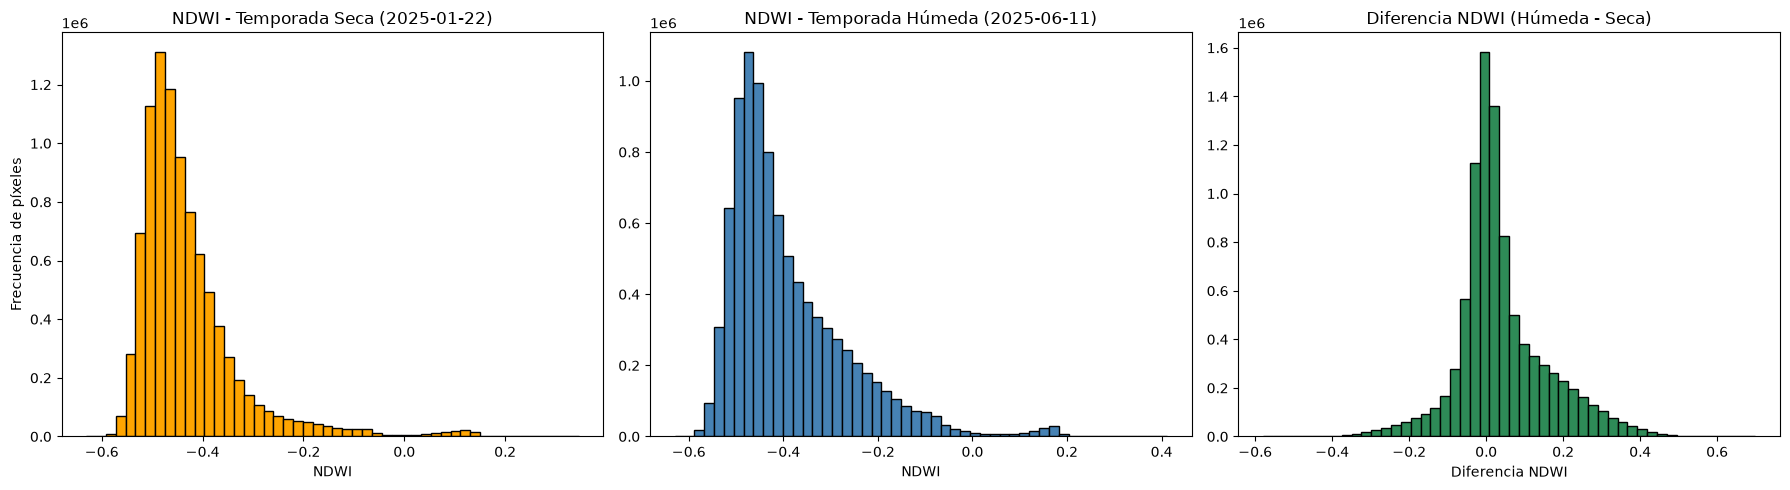

--- Estadísticas descriptivas ---

NDWI Seca:
  Media: -0.4295
  Mínimo: -0.6308
  Máximo: 0.3457
  Desv. estándar: 0.1023

NDWI Húmeda:
  Media: -0.3914
  Mínimo: -0.6299
  Máximo: 0.4114
  Desv. estándar: 0.1240

Diferencia:
  Media: 0.0380
  Mínimo: -0.5798
  Máximo: 0.6992
  Desv. estándar: 0.1171



In [48]:
#Importar librería que permite crear los gráficos.
import matplotlib.pyplot as plt
#Crea una ventana con 3 gráficos organizados horizontalmente. para el grafico de la temporada seca, humeda y la diferencia
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histograma NDWI temporada seca
axes[0].hist(ndwi_seca.flatten(), bins=50, color="orange", edgecolor="black")
axes[0].set_title("NDWI - Temporada Seca (2025-01-22)")
axes[0].set_xlabel("NDWI")
axes[0].set_ylabel("Frecuencia de píxeles")

# Histograma NDWI temporada húmeda
axes[1].hist(ndwi_humeda.flatten(), bins=50, color="steelblue", edgecolor="black")
axes[1].set_title("NDWI - Temporada Húmeda (2025-06-11)")
axes[1].set_xlabel("NDWI")

# Histograma de la diferencia
axes[2].hist(ndwi_diff.flatten(), bins=50, color="seagreen", edgecolor="black")
axes[2].set_title("Diferencia NDWI (Húmeda - Seca)")
axes[2].set_xlabel("Diferencia NDWI")

plt.tight_layout()
plt.show()

# Estadísticas descriptivas de las 3 capas
print("--- Estadísticas descriptivas ---\n")
#Lista de estadísticos
for nombre, arr in [("NDWI Seca", ndwi_seca), ("NDWI Húmeda", ndwi_humeda), ("Diferencia", ndwi_diff)]:
    print(f"{nombre}:")
    print(f"  Media: {arr.mean():.4f}")
    print(f"  Mínimo: {arr.min():.4f}")
    print(f"  Máximo: {arr.max():.4f}")
    print(f"  Desv. estándar: {arr.std():.4f}\n")

## 7.3. Visualización de resultados geográficos 
### Primero los datos de las imagenes tienen que pasarce a formato GeoTIF

In [49]:
def export_geotiff(array, transform, crs, output_path):
    meta = {
        "driver": "GTiff",
        "height": array.shape[0],
        "width": array.shape[1],
        "count": 1,
        "dtype": "float32",
        "crs": crs,
        "transform": transform,
    }
    with rasterio.open(output_path, "w", **meta) as dst:
        dst.write(array.astype(np.float32), 1)
    print(f"✅ Exportado: {output_path}")

# Se exportan las imagenes en el formato requerido
export_geotiff(ndwi_seca, out_transform, crs_seca, "ndwi_estado1_seca.tif")
export_geotiff(ndwi_humeda, out_transform, crs_seca, "ndwi_estado2_humeda.tif")
export_geotiff(ndwi_diff, out_transform, crs_seca, "ndwi_diferencia.tif")

✅ Exportado: ndwi_estado1_seca.tif
✅ Exportado: ndwi_estado2_humeda.tif
✅ Exportado: ndwi_diferencia.tif


### Visualización de las capas 1
### Permite visualizar cada uno de los tres resultados

In [51]:
centroid_aoi = gdf_aoi_seleccionado.to_crs(epsg=4326).geometry.centroid.iloc[0]

m2 = leafmap.Map(center=[centroid_aoi.y, centroid_aoi.x], zoom=13)
m2.add_basemap("Esri.WorldImagery")

m2.add_raster("ndwi_estado1_seca.tif", colormap="Blues", layer_name="Estado 1 - NDWI Seca", opacity=0.8)
m2.add_raster("ndwi_estado2_humeda.tif", colormap="Blues", layer_name="Estado 2 - NDWI Húmeda", opacity=0.8)
m2.add_raster("ndwi_diferencia.tif", colormap="RdYlGn", layer_name="Diferencia NDWI", opacity=0.8)

m2.add_layer_control()
m2

Map(center=[0.5411090000000001, -76.54955749999999], controls=(ZoomControl(options=['position', 'zoom_in_text'…

### Visualización de las capas 2 con la herramienta de spit
### Permite visualizar cada uno de los tres resultados de la temporada seca y húmeda mediante mediante la herramienta de split

In [53]:
m2_split = leafmap.Map(center=[centroid_aoi.y, centroid_aoi.x], zoom=13)

m2_split.split_map(
    left_layer="ndwi_estado1_seca.tif",
    right_layer="ndwi_estado2_humeda.tif",
    left_label="🌵 Temporada Seca (22-Ene-2025)",
    right_label="🌧️ Temporada Húmeda (11-Jun-2025)"
)

m2_split

Map(center=[0.541084, -76.5495155], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title'…